In [1]:
from pathlib import Path

ROOT = Path.cwd().resolve().parent

In [2]:
import pandas as pd

df_train = pd.read_csv(f"{ROOT}/data/processed/df_train.csv")

------- Pearson Correlation -------


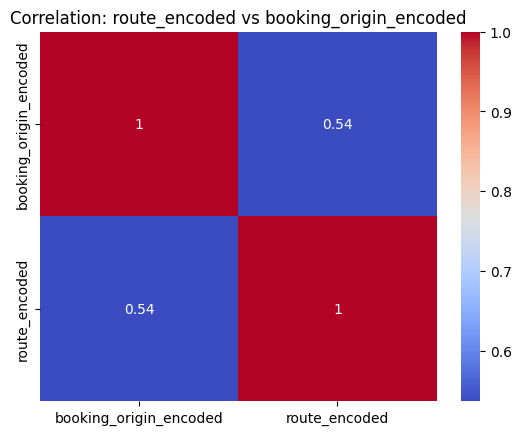

------- Mutual Information -------
Mutual Information Score: 1.3243


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression


corr_check = df_train[['booking_origin_encoded', 'route_encoded']]

corr = corr_check.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation: route_encoded vs booking_origin_encoded")
print("------- Pearson Correlation -------")
plt.show()


print("------- Mutual Information -------")
mi_score = mutual_info_regression(df_train[['route_encoded']], df_train['booking_origin_encoded'])[0]
print(f"Mutual Information Score: {mi_score:.4f}")

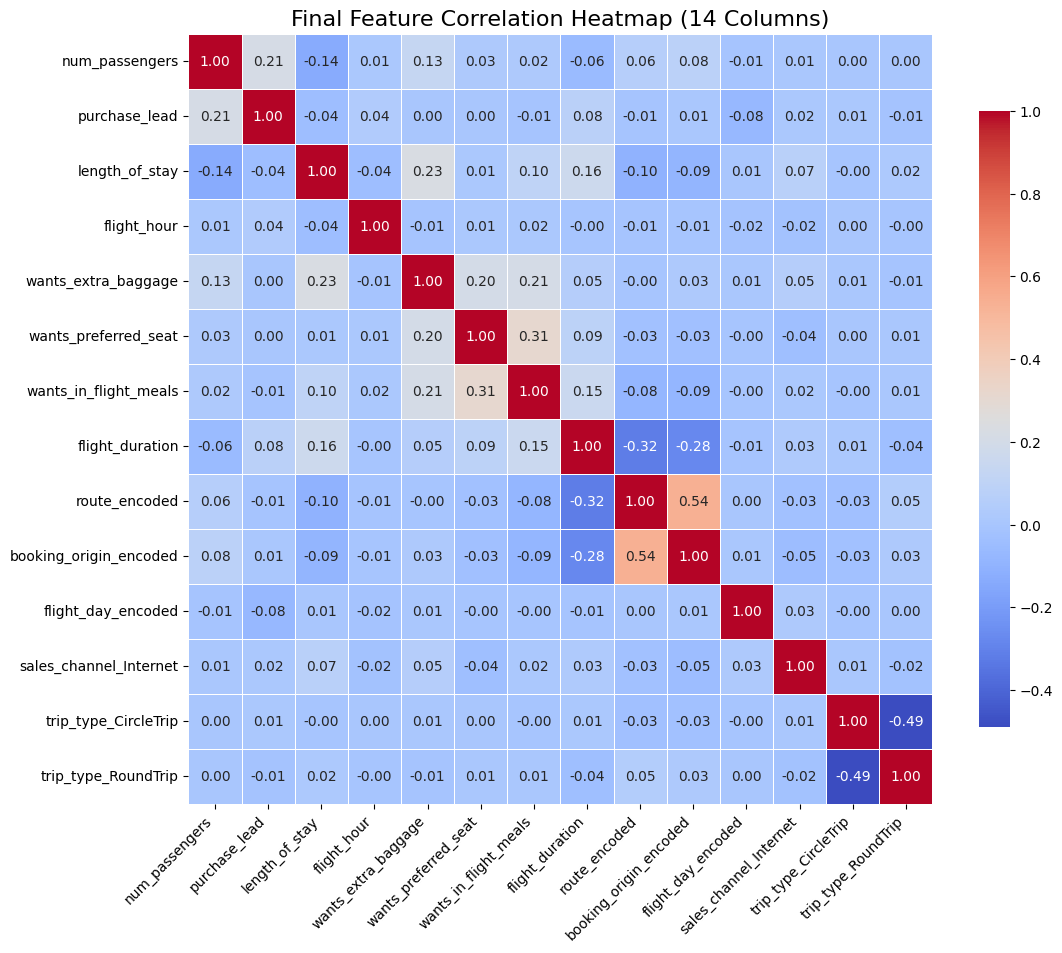

In [4]:
X_train = df_train.drop('booking_complete', axis = True)
features = X_train.columns 
corr_matrix = X_train[features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('Final Feature Correlation Heatmap (14 Columns)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()